# Jupyter Notebook for validating the Overture TPU structures.

Import Libraries

In [24]:
import csv
import numpy as np
from matplotlib import pyplot as plt
from TensegritySim import Node, Connection, Tensegrity, TensegritySolver
from TensegritySim import NonLinProps, ConnectionNonLinear
from Array1 import Inner_distance # mm
# from scipy.optimize import minimize
from Stiffnesses import k_fl, k_Al


In [25]:
string = Connection.ConnectionType.STRING
bar = Connection.ConnectionType.BAR
string_nonlin = ConnectionNonLinear.ConnectionType.STRING

masses = np.arange(0., 651., 50.) / 1000 # kg
forces = masses * 9.8 # N

Stress-Strain data for Overture TPU

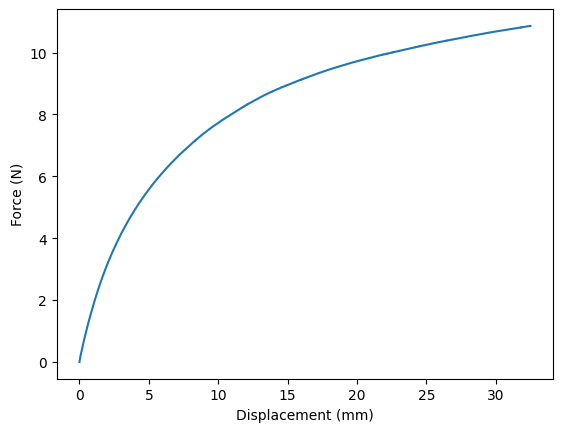

In [26]:
Strain_list = []
Stress_list = []
with open("Tables/Avg_Stress_Strain_Overture_TPU.csv", "r", newline="") as csvfile0:
    reader = csv.DictReader(csvfile0)
    for row in reader:
        Strain_list.append(float(row["Strain"])) # %
        Stress_list.append(float(row["Stress (MPa)"])) # MPa
strain = np.array(Strain_list)
stress = np.array(Stress_list)

# linear approximation for k_TPU
length = 65. # mm, gauge length
area = 1.2 * 1.2 # mm**2, cross-sectional area
displacement = strain * length # mm
force = stress * area # N

plt.plot(displacement, force)
plt.xlabel("Displacement (mm)")
plt.ylabel("Force (N)")
plt.show()
plt.close()

In [27]:
min_slope = np.inf
max_slope = 0
for num_points in range(1, 15001):
    slope, intercept = np.polyfit(displacement[:num_points+1], force[:num_points+1], 1)
    if slope < min_slope:
        min_slope = slope
    if slope > max_slope:
        max_slope = slope
print(f"Min slope: {min_slope} N/mm") # 0.2444
print(f"Max slope: {max_slope} N/mm") # 2.842

Min slope: 0.24438342453928008 N/mm
Max slope: 2.8422980212817373 N/mm


# Array 1

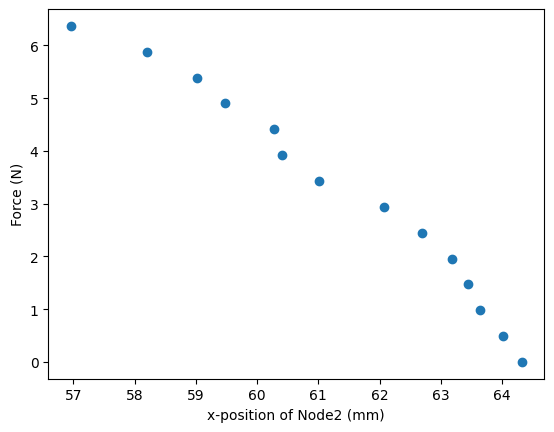

In [28]:
inner_distances1 = Inner_distance # mm

plt.scatter(inner_distances1, forces, label="Measured")
plt.xlabel("x-position of Node2 (mm)")
plt.ylabel("Force (N)")
plt.show()
plt.close()


The ideal linear stiffness value for array 1

In [29]:
errors = []
min_error = np.inf
stiffnesses = np.linspace(min_slope, max_slope, num=151)
for k_TPU in stiffnesses: # For each stiffness value
    node1 = Node(name="A", position=np.array([0., 0.]))
    node2 = Node(name="B", position=np.array([65., 0.]))
    node3 = Node(name="C", position=np.array([63.25, 62.5]))
    node4 = Node(name="D", position=np.array([1.75, 62.5]))
    nodes = [node1, node2, node3, node4]

    connection1 = Connection(nodes=[node1, node2], connection_type=string, stiffness=k_fl, name="control_string")
    connection2 = Connection(nodes=[node2, node3], connection_type=string, stiffness=k_TPU)
    connection3 = Connection(nodes=[node3, node4], connection_type=string, stiffness=k_TPU)
    connection4 = Connection(nodes=[node4, node1], connection_type=string, stiffness=k_TPU)
    connection5 = Connection(nodes=[node1, node3], connection_type=bar, stiffness=k_Al)
    connection6 = Connection(nodes=[node2, node4], connection_type=bar, stiffness=k_Al)
    connections = [connection1, connection2, connection3, connection4, connection5, connection6]

    pins = {"A": [True, True],
            "B": [False, True],
            "C": [False, False],
            "D": [False, False]}

    controls = [connection1]

    # Create the tensegrity system
    tensegrity_system = Tensegrity(nodes, connections, pins, controls)
    solver = TensegritySolver(tensegrity_system)
    solver.solve()

    length_change = 0.0 # mm, initial length change
    tensions = []
    for i in range(len(inner_distances1)): # For each displacement value
        tensegrity_system.change_control_lengths(length_change)
        solver.solve()
        # get and store the force on the control string
        tensions.append(connection1.force)
        if i < len(inner_distances1) - 1:
            length_change = inner_distances1[i+1] - inner_distances1[i]

    error = np.sqrt(np.mean((np.array(tensions) - forces)**2)) # RMSE
    errors.append(error)
    if error < min_error:
        min_error = error
        best_k_TPU = k_TPU
        best_tensions = tensions.copy()
# Return the stiffness with the lowest error
print(f"Best k_TPU: {best_k_TPU} N/mm with RMSE: {min_error}")

Best k_TPU: 2.8422980212817373 N/mm with RMSE: 0.5859362102359076


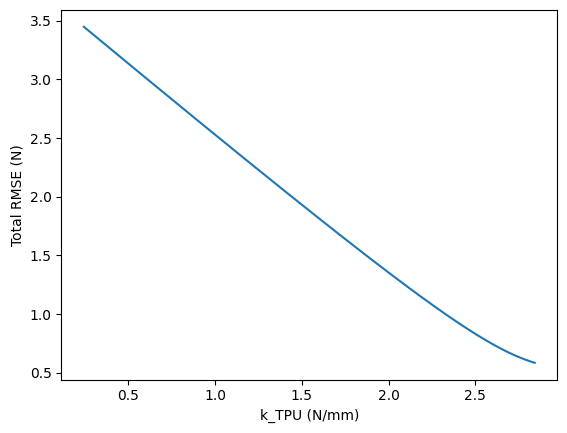

In [30]:
plt.plot(stiffnesses, errors)
plt.xlabel("k_TPU (N/mm)")
plt.ylabel("Total RMSE (N)")
plt.show()
plt.close()

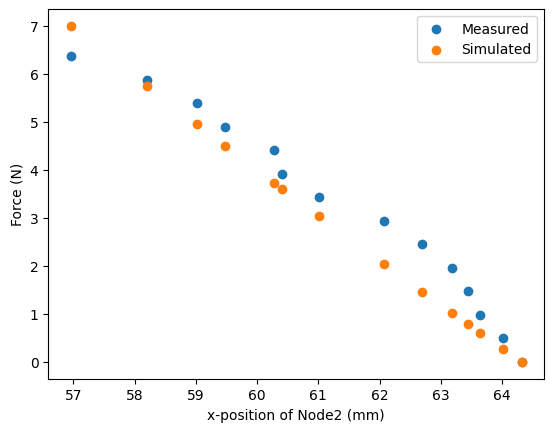

In [31]:
plt.scatter(inner_distances1, forces, label="Measured", marker='o')
plt.scatter(inner_distances1, best_tensions, label="Simulated", marker='o')
plt.xlabel("x-position of Node2 (mm)")
plt.ylabel("Force (N)")
plt.legend()
plt.show()
plt.close()

## Simulation using lookup table
Create a Nonlinear Connection class which inherits from Connection \
Have the solver check to see if the connection is linear or nonlinear \
Use numerical integration to calculate the energy stored in each connection \
Use a lookup table to calculate C for each connection based on its current length and the stress-strain curve

l \
epsilon = (l - l_0) / l_0 \
use interpolation to get sigma from epsilon \
F = sigma * A \
C = -F

In [32]:
# Create the Tensegrity Object
# nodes
node1 = Node(name="A", position=np.array([0., 0.]))
node2 = Node(name="B", position=np.array([65., 0.]))
node3 = Node(name="C", position=np.array([63.25, 62.5]))
node4 = Node(name="D", position=np.array([1.75, 62.5]))
nodes = [node1, node2, node3, node4]
# connections
connection1 = Connection(nodes=[node1, node2], connection_type=string, stiffness=k_fl, name="control_string")

connection5 = Connection(nodes=[node1, node3], connection_type=bar, stiffness=k_Al)
connection6 = Connection(nodes=[node2, node4], connection_type=bar, stiffness=k_Al)
connections = [connection1, connection5, connection6]
# pins
# control

# Create the Solver
# Solve
# Display the measured, linear, and nonlinear results
# Return the RMSE for linear and nonlinear results

# Array 3

Force vs. Displacement data for Array 3

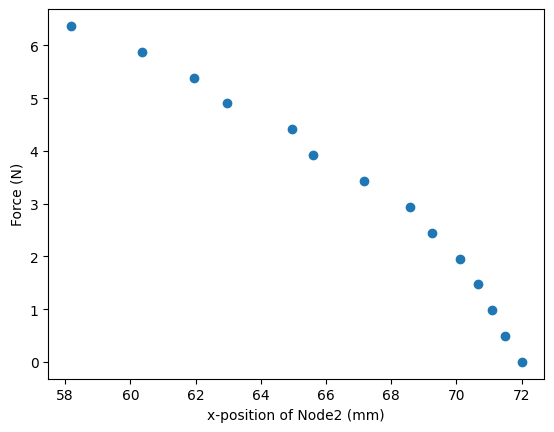

In [34]:
masses3 = []
inner_distances3 = []
with open("Tables/Array 3.csv", newline="") as csvfile3:
    reader = csv.DictReader(csvfile3)
    for row in reader:
        masses3.append(float(row["Mass (g)"])) # g
        inner_distances3.append(float(row["Inner Distance (mm)"])) # mm
masses3 = np.array(masses3) / 1000 # kg
distances3 = (np.array(inner_distances3) + 11.67) # mm

masses3 = masses3[::3]
masses3 = np.array(masses3)
masses3 = np.insert(masses3, 0, 0.0) # kg
forces = masses3 * 9.8 # N

trial_3_1 = distances3[::3]
trial_3_1 = np.array(trial_3_1)
# add zero at the beginning
trial_3_1 = np.insert(trial_3_1, 0, 72.0) # mm

plt.scatter(trial_3_1, forces, label="Measured", marker='o')
plt.ylabel("Force (N)")
plt.xlabel("x-position of Node2 (mm)")
plt.show()
plt.close()

In [35]:
errors = []
min_error = np.inf
# stiffnesses = np.linspace(min_slope, max_slope, num=151)
stiffnesses = np.linspace(1.25, 1.75, num = 151)
for k_TPU in stiffnesses: # For each stiffness value
    node1 = Node(name="A", position=np.array([0., 0.]))
    node2 = Node(name="B", position=np.array([68.12, 0.]))
    node3 = Node(name="C", position=np.array([68.12, 68.12]))
    node4 = Node(name="D", position=np.array([0., 68.12]))
    nodes = [node1, node2, node3, node4]

    connection1 = Connection(nodes=[node1, node2], connection_type=string, stiffness=k_fl, name="control_string")
    connection2 = Connection(nodes=[node2, node3], connection_type=string, stiffness=k_TPU)
    connection3 = Connection(nodes=[node3, node4], connection_type=string, stiffness=k_TPU)
    connection4 = Connection(nodes=[node4, node1], connection_type=string, stiffness=k_TPU)
    connection5 = Connection(nodes=[node1, node3], connection_type=bar, stiffness=k_Al)
    connection6 = Connection(nodes=[node2, node4], connection_type=bar, stiffness=k_Al)
    connections = [connection1, connection2, connection3, connection4, connection5, connection6]

    pins = {"A": [ True,  True],
            "B": [False,  True],
            "C": [False, False],
            "D": [False, False]}

    controls = [connection1]

    tensegrity_system = Tensegrity(nodes, connections, pins, controls)
    solver = TensegritySolver(tensegrity_system)
    solver.solve()

    tensions = []
    length_change = 0.0 # mm, initial length change
    for i in range(len(trial_3_1)): # For each displacement value
        tensegrity_system.change_control_lengths(length_change)
        solver.solve()
        # get and store the force on the control string
        tensions.append(connection1.force)
        if i < len(trial_3_1) - 1:
            length_change = trial_3_1[i+1] - trial_3_1[i]

    error = np.sqrt(np.mean((np.array(tensions) - forces)**2)) # RMSE
    errors.append(error)
    if error < min_error:
        min_error = error
        best_k_TPU = k_TPU
        best_tensions = tensions

print(f"Best k_TPU: {best_k_TPU} N/mm with error: {min_error}")

Best k_TPU: 1.5 N/mm with error: 0.7454641990425466


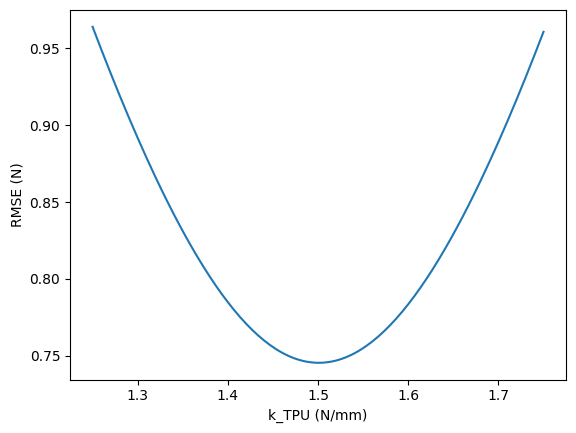

In [36]:
plt.plot(stiffnesses, errors)
plt.xlabel("k_TPU (N/mm)")
plt.ylabel("RMSE (N)")
plt.show()
plt.close()

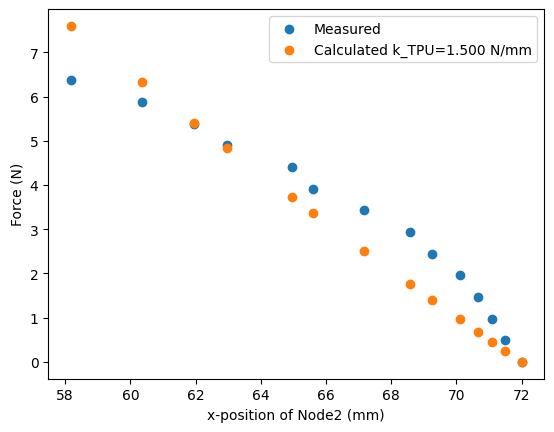

In [37]:
plt.scatter(trial_3_1, forces, label="Measured")
plt.scatter(trial_3_1, best_tensions, label=f"Calculated k_TPU={best_k_TPU:.3f} N/mm")
plt.xlabel("x-position of Node2 (mm)")
plt.ylabel("Force (N)")
plt.legend()
plt.show()
plt.close()

# Both Arrays

In [38]:
stiffnesses = np.linspace(1.75, 1.85, num=151)
min_error = np.inf
errors = []
for k_TPU in stiffnesses: # For each stiffness value
    # Set up the tensegrity system for array 1
    node1_1 = Node(name="A", position=np.array([0., 0.]))
    node1_2 = Node(name="B", position=np.array([65., 0.]))
    node1_3 = Node(name="C", position=np.array([63.25, 62.5]))
    node1_4 = Node(name="D", position=np.array([1.75, 62.5]))
    nodes1 = [node1_1, node1_2, node1_3, node1_4]

    connection1_1 = Connection(nodes=[node1_1, node1_2], connection_type=string, stiffness=k_fl, name="control_string1")
    connection1_2 = Connection(nodes=[node1_2, node1_3], connection_type=string, stiffness=k_TPU)
    connection1_3 = Connection(nodes=[node1_3, node1_4], connection_type=string, stiffness=k_TPU)
    connection1_4 = Connection(nodes=[node1_4, node1_1], connection_type=string, stiffness=k_TPU)
    connection1_5 = Connection(nodes=[node1_1, node1_3], connection_type=bar, stiffness=k_Al)
    connection1_6 = Connection(nodes=[node1_2, node1_4], connection_type=bar, stiffness=k_Al)
    connections1 = [connection1_1, connection1_2, connection1_3, connection1_4, connection1_5, connection1_6]

    pins1 = {"A": [ True,  True],
             "B": [False,  True],
             "C": [False, False],
             "D": [False, False]}
        
    controls1 = [connection1_1]

    tensegrity_system1 = Tensegrity(nodes1, connections1, pins1, controls1)
    solver1 = TensegritySolver(tensegrity_system1)
    solver1.solve()

    # Set up the tensegrity system for array 3
    node3_1 = Node(name="A", position=np.array([0., 0.]))
    node3_2 = Node(name="B", position=np.array([68.12, 0.]))
    node3_3 = Node(name="C", position=np.array([68.12, 68.12]))
    node3_4 = Node(name="D", position=np.array([0., 68.12]))
    nodes3 = [node3_1, node3_2, node3_3, node3_4]

    connection3_1 = Connection(nodes=[node3_1, node3_2], connection_type=string, stiffness=k_fl, name="control_string3")
    connection3_2 = Connection(nodes=[node3_2, node3_3], connection_type=string, stiffness=k_TPU)
    connection3_3 = Connection(nodes=[node3_3, node3_4], connection_type=string, stiffness=k_TPU)
    connection3_4 = Connection(nodes=[node3_4, node3_1], connection_type=string, stiffness=k_TPU)
    connection3_5 = Connection(nodes=[node3_1, node3_3], connection_type=bar, stiffness=k_Al)
    connection3_6 = Connection(nodes=[node3_2, node3_4], connection_type=bar, stiffness=k_Al)
    connections3 = [connection3_1, connection3_2, connection3_3, connection3_4, connection3_5, connection3_6]

    pins3 = {"A": [ True,  True],
             "B": [False,  True],
             "C": [False, False],
             "D": [False, False]}
    
    controls3 = [connection3_1]

    tensegrity_system3 = Tensegrity(nodes3, connections3, pins3, controls3)
    solver3 = TensegritySolver(tensegrity_system3)
    solver3.solve()

    tensions_1 = []
    tensions_3 = []
    length_change_1 = 0.0 # mm, initial length change
    length_change_3 = 0.0 # mm, initial length change
    for i in range(14):
        # Array 1
        tensegrity_system1.change_control_lengths(length_change_1)
        solver1.solve()
        tensions_1.append(connection1_1.force)
            
        # Array 3
        tensegrity_system3.change_control_lengths(length_change_3)
        solver3.solve()
        tensions_3.append(connection3_1.force)
        
        if i < 13:
            length_change_1 = inner_distances1[i+1] - inner_distances1[i]
            length_change_3 = trial_3_1[i+1] - trial_3_1[i]

    error_1 = np.sqrt(np.mean((np.array(tensions_1) - forces)**2)) # RMSE
    error_3 = np.sqrt(np.mean((np.array(tensions_3) - forces)**2)) # RMSE
    total_error = np.linalg.norm([error_1, error_3])
    errors.append(total_error)
    if total_error < min_error:
        best_k_TPU = k_TPU
        min_error = total_error
        best_error_1 = error_1
        best_error_3 = error_3
        best_tensions_1 = tensions_1
        best_tensions_3 = tensions_3

print(f"Best k_TPU: {best_k_TPU}")
print(f"With error 1: {best_error_1}, and error 3: {best_error_3}")

Best k_TPU: 1.8073333333333335
With error 1: 1.573983669066418, and error 3: 1.0542859953561896


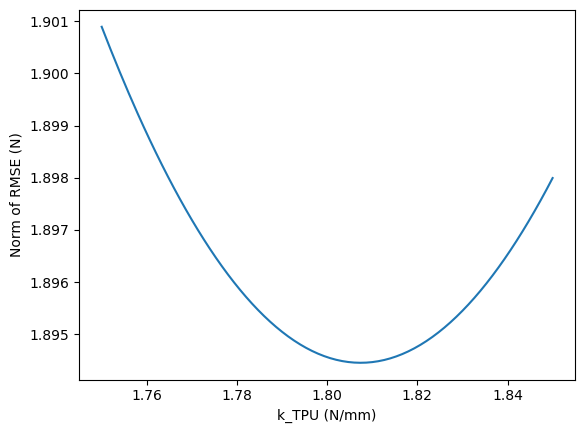

In [39]:
plt.plot(stiffnesses, errors)
plt.xlabel("k_TPU (N/mm)")
plt.ylabel("Norm of RMSE (N)")
plt.show()
plt.close()

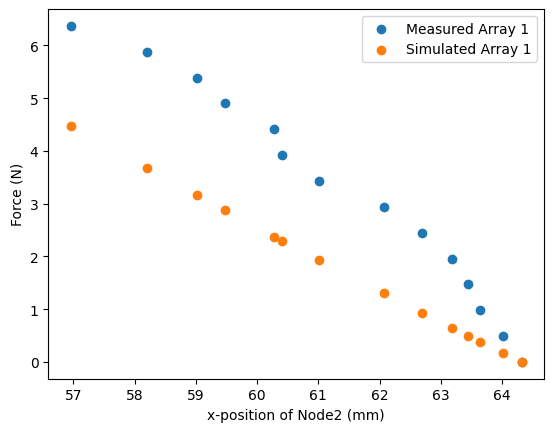

In [40]:
plt.scatter(inner_distances1, forces, label="Measured Array 1", marker='o')
plt.scatter(inner_distances1, best_tensions_1, label="Simulated Array 1", marker='o')
plt.xlabel("x-position of Node2 (mm)")
plt.ylabel("Force (N)")
plt.legend()
plt.show()
plt.close()

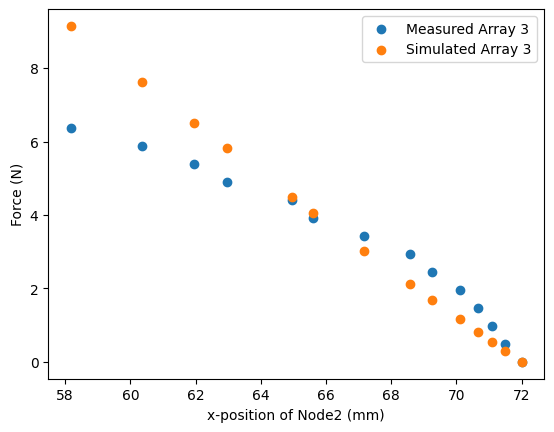

In [41]:
plt.scatter(trial_3_1, forces, label="Measured Array 3", marker='o')
plt.scatter(trial_3_1, best_tensions_3, label="Simulated Array 3", marker='o')
plt.xlabel("x-position of Node2 (mm)")
plt.ylabel("Force (N)")
plt.legend()
plt.show()
plt.close()